In [1]:
%load_ext autoreload
%autoreload 2

### Setup

In [2]:
import os, sys
sys.path.append(os.path.dirname(os.getcwd())) # Add the parent directory to sys.path

import json
import pandas as pd
import numpy as np

from utils import DATA_DIR
from download.weka import pull_predictions_from_weka

from dataloader import get_nd_array, get_slice

In [3]:
pull_predictions_from_weka("consistent_ranking")

File already exists and matches size: /Users/dhei/ai2/new-evals/analysis/data/all_consistent_ranking_predictions.parquet


In [4]:
COLS = ['step', 'model', 'task', 'mix', 'size', 'token_ratio', 'native_id', 'acc_per_char'] # load a subset of columns to save on memory

df = pd.read_parquet(f'{DATA_DIR}/all_consistent_ranking_predictions.parquet', columns=COLS)

In [377]:
MODELS = df.index.get_level_values('model').unique().to_list()
TASKS  = df.index.get_level_values('task').unique().to_list()
MIXES  = df.index.get_level_values('mix').unique().to_list()
SIZES  = df['size'].unique()
TOKEN_RATIO = df['token_ratio'].unique()

MMLU  = [t for t in TASKS if 'mmlu' in t]
TASKS = [t for t in TASKS if 'mmlu' not in t]
TASKS = sorted(TASKS)

### Significance Comparison

In [ ]:
from stats import compute_significance

# models = [model for model in MODELS if '300M' in model]
# models = [model for model in MODELS if '1B' in model]

# _, _ = compute_significance(df, models, 'acc_per_char', tasks=['arc_easy', 'arc_challenge'], do_plot=True)
# _, _ = compute_significance(df, models, 'acc_per_char', last_n=10, alpha=0.001, tasks=['arc_easy', 'arc_challenge', 'csqa', 'boolq'], do_plot=True)
# _, _ = compute_significance(df, models, 'acc_per_char', last_n=10, alpha=0.001, tasks=['arc_easy', 'arc_challenge', 'csqa', 'boolq'], do_plot=True)


### Model Decisions

Computing pairwise comparisons: 100%|██████████| 1/1 [00:05<00:00,  5.09s/it]


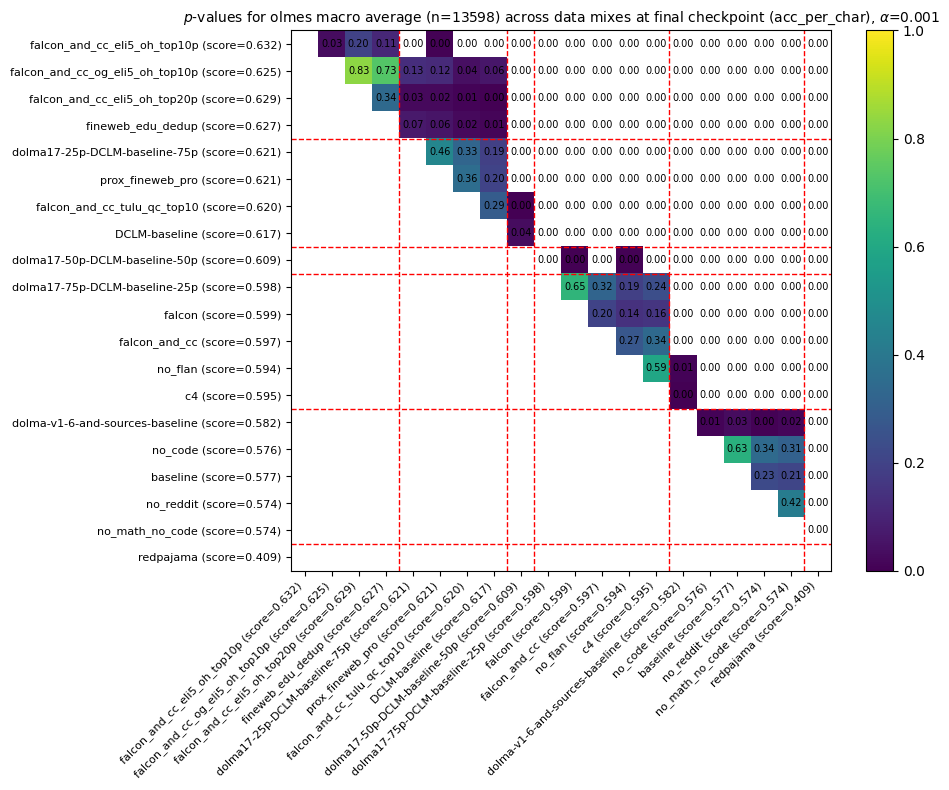

In [420]:
# Algorithm:
# Step 1: Run comparison
# Step 2: Get the models in the top significance cluster
#         Track the total compute used so far
# Step 3: Repeat at larger scale
# Step 4: Compute P/R/F1 of whether the final 3 mixes match the top signifiance cluster at 1B scale

# Example: Pairwise significance between mixes on OLMES at 1B (this is our gold-standard!)
models = [model for model in MODELS if '1B' in model]
olmes  = [task for task in TASKS if ':para' not in task and 'hellaswag' not in task]

# _, p_values, _ = compute_significance(df, models, 'acc_per_char', last_n=10, alpha=0.001, tasks=['arc_challenge'], do_plot=True)
# _, p_values, _ = compute_significance(df, models, 'acc_per_char', last_n=10, alpha=0.001, tasks=olmes, do_plot=True)
_, p_values, _ = compute_significance(df, models, 'acc_per_char', last_n=1, alpha=0.001, tasks=[olmes], do_plot=True)

In [ ]:
import os, sys
sys.path.append('/Users/dhei/ai2/new-evals/olmo-repos/OLMo/scripts') 
# from scripts.scaling.flops_calculation import MODEL_FLOPS

# VERY ROUGH ESTIMATION PROBABLY NOT EXACT!
MODEL_FLOPS = {
    '150M': 1903391232,
    '300M': 3443922944,
    '530M': 5180751744,
    '750M': 6373843968,
    '1B': 10109071360
}

MODEL_PARAMS = {
    "150M": 190354176,
    "300M": 371262464,
    "530M": 597382464,
    "750M": 758220288,
    "1B": 1279395840,
}

def compute_flops(N, mult):
    """ Taken from Model Ladder code in OLMo """
    return MODEL_FLOPS[N] * (MODEL_PARAMS[N] * 20 * mult)

In [438]:
from stats import convert_sci, compute_f1, get_sig_clusters

def simulate_mix_selection(method, sizes, mixes, task, mult=None, top_n_clusters=None, alpha=None, quiet=True):
    """ Simulate training and rejecting mixes for TASK in the order of SIZES """
    curr_mixes = mixes
    cumulative_compute = 0

    for curr_size in sizes:
        curr_models = [model for model in MODELS if (curr_size in model) and any(mix in model for mix in curr_mixes)]
        
        if mult is None: raise RuntimeError(f'Must specify chilchilla multiplier to compute FLOPS!')

        cumulative_compute += len(curr_models) * compute_flops(curr_size, mult)
        if len(curr_models) == 1: continue # don't compute significance table if there's only one model

        last_n = 10
        if curr_size == '150M':
            print('manual override for last_n=1!')
            last_n = 1
        elif isinstance(task, list):
            print('manual override for last_n=1!')
            last_n = 1

        _, p_values, _ = compute_significance(df, curr_models, 'acc_per_char', last_n=last_n, alpha=alpha, tasks=[task], do_plot=False, quiet=quiet)

        if isinstance(task, list): 
            task_name = 'olmes macro average' # TMP: WONT WORK ON OTHER TASK SETS
        else:
            task_name = task

        mixes, scores, p_vals = p_values[task_name]

        if method == 'baseline':
            # Method 2: Only keep the top performing mixes
            curr_mixes = mixes[:len(mixes) // 4]
        elif method == 'perc_sig':
            # Method 2: Keep the top significance clusters
            sig_clusters = get_sig_clusters(p_vals, alpha=alpha)
            curr_mixes = np.array(mixes)[sig_clusters < top_n_clusters].tolist()
        else:
            raise ValueError(method)

        if not quiet: print(curr_size, curr_mixes, '\n')

    pred_mixes = curr_mixes
    return pred_mixes, cumulative_compute


top_n_clusters = 1 # How many significance clusters to keep for the next step
alpha = 0.001 # Significance level for cluster calculations

SORTED_SIZES = ['150M'] # '300M', '530M', '750M', '1B'] # SIZES

gold_mixes, gold_compute = simulate_mix_selection('perc_sig', ['1B'], MIXES, 'arc_challenge', mult=5, top_n_clusters=top_n_clusters, alpha=alpha)

pred_mixes, pred_compute = simulate_mix_selection('perc_sig', SORTED_SIZES, MIXES, 'arc_challenge', mult=5, top_n_clusters=top_n_clusters, alpha=alpha)

print(convert_sci(gold_compute), convert_sci(pred_compute))
print(compute_f1(gold_mixes, pred_mixes))

manual override for last_n=1!
2.59 * 10^22 7.25 * 10^20
(0.3333333333333333, 1.0, 0.5)


In [427]:
from itertools import combinations
from tqdm import tqdm

def run_simulations(sorted_sizes, task, top_n_clusters, top_n_clusters_eval, alpha, model_pool='prefix', quiet=True):
    results = []

    # Baseline: Train all mixes at 1B scale
    gold_mixes, gold_compute = simulate_mix_selection('perc_sig', ['1B'], MIXES, task, mult=5, top_n_clusters=top_n_clusters_eval, alpha=alpha)
    results += [(['1B'], gold_compute, (1, 1, 1))]

    if model_pool == 'prefix':
        # Get prefixes of model sizes (n runs)
        SIZE_SETS = []
        for size_idx in range(1, len(sorted_sizes)+1):
            SIZE_SETS += [sorted_sizes[:size_idx]]
    elif model_pool == 'combination':
        # Generate all combinations preserving order (2^n runs)
        SIZE_SETS = [list(sorted_sizes[:i]) for i in range(1, len(sorted_sizes) + 1)]
        for r in range(2, len(sorted_sizes)):
            SIZE_SETS += [list(combo) for combo in combinations(sorted_sizes, r)]
        SIZE_SETS.sort(key=lambda x: (len(x), x))
    else: raise ValueError(model_pool)

    for selected_sizes in tqdm(SIZE_SETS, desc=f'Running simulations for {task}'):
        if not quiet: print(selected_sizes)
        pred_mixes, pred_compute = simulate_mix_selection('perc_sig', selected_sizes, MIXES, task, mult=5, top_n_clusters=top_n_clusters, alpha=alpha)

        p, r, f1 = compute_f1(gold_mixes, pred_mixes)

        if not quiet: print(convert_sci(gold_compute), convert_sci(pred_compute))
        if not quiet: print(p, r, f1, '\n')

        results += [(selected_sizes, pred_compute, (p, r, f1))]

    if not quiet: print(gold_mixes, pred_mixes)

    return results

# task = 'boolq'
# task = 'arc_easy'
task = 'arc_challenge'
# task = 'csqa'

# SORTED_SIZES = ['300M', '530M', '750M', '1B'] # SIZES
# SORTED_SIZES = ['150M', '300M', '530M', '750M', '1B']
SORTED_SIZES = ['150M', '300M', '530M', '750M']

results = run_simulations(
    sorted_sizes=SORTED_SIZES,
    task='arc_challenge',
    top_n_clusters=2, # How many significance clusters to keep for the next step
    top_n_clusters_eval=1, # How many significance clusters we want at the target scale
    alpha=0.001, # Significance level for cluster calculations
)

Running simulations for arc_challenge: 100%|██████████| 4/4 [00:06<00:00,  1.74s/it]


How to interpret: We want high *recall* scores for low compute (i.e., we want to minimize false negatives, where we would throw away a potentially good mix):


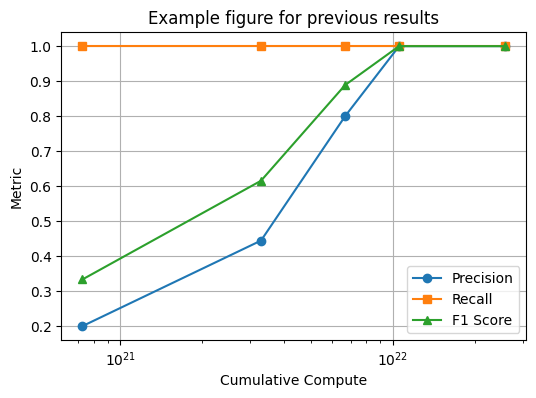

In [464]:
import matplotlib.pyplot as plt
from adjustText import adjust_text
import math

def plot_simulation_results(results, ax):
    results = sorted(results, key=lambda x: x[1])

    # x_values = [np.log10(float(d[0])) for d in results]
    labels        = [d[0] for d in results]
    x_values      = [d[1] for d in results]
    prec_values   = [d[2][0] for d in results]
    recall_values = [d[2][1] for d in results]
    f1_values     = [d[2][2] for d in results]

    x_values = np.array(x_values, dtype=np.float64)

    ax.plot(x_values, prec_values, label="Precision", marker='o')
    ax.plot(x_values, recall_values, label="Recall", marker='s')
    ax.plot(x_values, f1_values, label="F1 Score", marker='^')

    ax.set_xlabel("Cumulative Compute")
    ax.set_ylabel("Metric")
    ax.legend()
    ax.grid(True)

    # # Add labels near each point
    # texts = []
    # for i, (x, y) in enumerate(zip(x_values, prec_values)):
    #     texts += [ax.text(x, y*(1+(0.02*i)), f"{labels[i]}", fontsize=8, ha='right', va='bottom')]

    # adjust_text(
    #     texts,
    #     arrowprops=dict(arrowstyle="->", color='gray', lw=0.5),
    #     force_text=(1, 1),  # Stronger force to push text labels apart
    #     expand_text=(1, 1),  # Increase spacing around text
    #     lim=300  # Increase the iterations to ensure better optimization
    # )

    # Add log scale
    ax.set_xscale('log')

    return ax

print('How to interpret: We want high *recall* scores for low compute (i.e., we want to minimize false negatives, where we would throw away a potentially good mix):')

fig, ax = plt.subplots(figsize=(6, 4))
ax.set_title('Example figure for previous results')
plot_simulation_results(results, ax)
plt.show()

Running simulations for arc_challenge:   0%|          | 0/4 [00:00<?, ?it/s]

manual override for last_n=1!


Running simulations for arc_challenge:  25%|██▌       | 1/4 [00:00<00:02,  1.47it/s]

manual override for last_n=1!


Running simulations for arc_challenge:  50%|█████     | 2/4 [00:02<00:02,  1.14s/it]

manual override for last_n=1!


Running simulations for arc_challenge:  75%|███████▌  | 3/4 [00:04<00:01,  1.55s/it]

manual override for last_n=1!


Running simulations for arc_challenge: 100%|██████████| 4/4 [00:06<00:00,  1.70s/it]


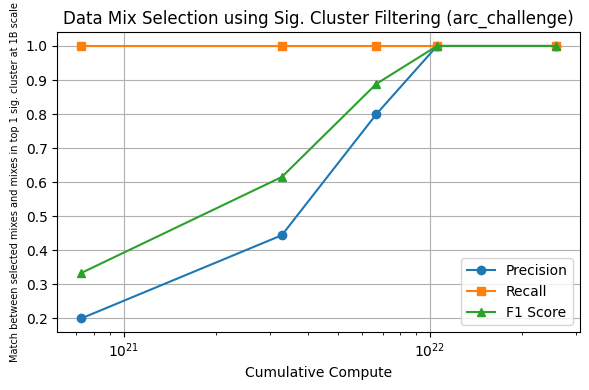

In [465]:
SORTED_SIZES = ['150M', '300M', '530M', '750M'] # '1B'
tasks = [task for task in TASKS if 'hellaswag' not in task and ':para' not in task]

tasks = tasks[:1]
# tasks = [tasks]

fig, axes = plt.subplots(len(tasks), 1, figsize=(6, 4*len(tasks)), sharex=True, sharey=True)

for i, task in enumerate(tasks):
    ax = axes[i] if len(tasks) > 1 else axes
    
    results = run_simulations(
        sorted_sizes=SORTED_SIZES,
        task=task,
        top_n_clusters=2, # How many significance clusters to keep for the next step
        top_n_clusters_eval=1, # How many significance clusters we want at the target scale
        alpha=0.001, # Significance level for cluster calculations
        model_pool='prefix', # How to select which sizes to test (prefix, combination)
    )
    
    plot_simulation_results(results, ax)
    task_name = task if not isinstance(task, list) else "OLMES Avg"
    ax.set_title(f"Data Mix Selection using Sig. Cluster Filtering ({task_name})")
    ax.set_ylabel(f"Match between selected mixes and mixes in top 1 sig. cluster at 1B scale", fontsize=7)
    
fig.tight_layout()
plt.show()

In [ ]:
# TODO: Ablations

# Can we keep the adjust the alpha?
# Can we adjust the top-n clusters for filtering?
# Can we adjust the top-n clusters for evaluation?

### Dev: Computing OLMES avg with MMLU

In [ ]:
# TODO: 
    # Create rejection simulator (i.e., a rule for rejecting mixes and a final score of the number of desired mixes remaining at 1B scale, along with the cumulative compute)
    # Calculate SPA (we can interpret whether we "trust" the stat sig results by looking at SPA and the rejection metric)

In [ ]:
# Dev: Adding support for OLMES AVG and MMLU

models = [model for model in MODELS if '1B' in model]

mixes, scores = get_nd_array(df, ['mix', 'step'], 'acc_per_char', model=models, task=['arc_challenge', 'arc_easy'], step='max')

In [ ]:
from stats import create_stratified_array
from utils.pce import compute_weighted_pairwise_p_values

models = [model for model in MODELS if '1B' in model]

mixes, scores = get_nd_array(df, ['mix', 'step'], 'acc_per_char', model=models, task=['arc_challenge', 'arc_easy'], step='max')

# # compute unweighted p-values
# p_values = compute_pairwise_p_values(scores)
# p_values[2, 3]

# compute weighted p-values
slices = get_slice(df, model=models, task=['arc_challenge', 'arc_easy'])
unique_counts = slices.groupby('task')['native_id'].nunique()
scores = scores[:, 0, :]
weights = create_stratified_array(unique_counts)
p_values = compute_weighted_pairwise_p_values(scores, weights=weights)

p_values[2, 3]

0.017

In [ ]:
np.unique(weights, return_counts=True)

(array([ 500., 1172., 1221., 1267., 1838., 1954., 2376., 3270.]),
 array([ 500, 1172, 1221, 1267, 1838, 1954, 2376, 3270]))

In [ ]:
mmlu = [task for task in MMLU+TASKS if ':para' not in task and 'hellaswag' not in task]

mixes, scores = get_nd_array(df, 'mix', 'acc_per_char', model=models, task=mmlu, step='max', sorted=True)
slices = get_slice(df, model=models, task=mmlu)
unique_counts = slices.groupby('task')['native_id'].nunique() # new
weights = create_stratified_array(unique_counts) # new

In [ ]:
weights

array([1172., 1172., 1172., ..., 1267., 1267., 1267.])

In [ ]:
weights.sum()

34839244.0

In [ ]:
unique_counts

task
arc_challenge            1172
arc_easy                 2376
boolq                    3270
csqa                     1221
mmlu_abstract_algebra     100
                         ... 
mmlu_world_religions      171
openbookqa                500
piqa                     1838
socialiqa                1954
winogrande               1267
Name: native_id, Length: 65, dtype: int64

<Axes: >

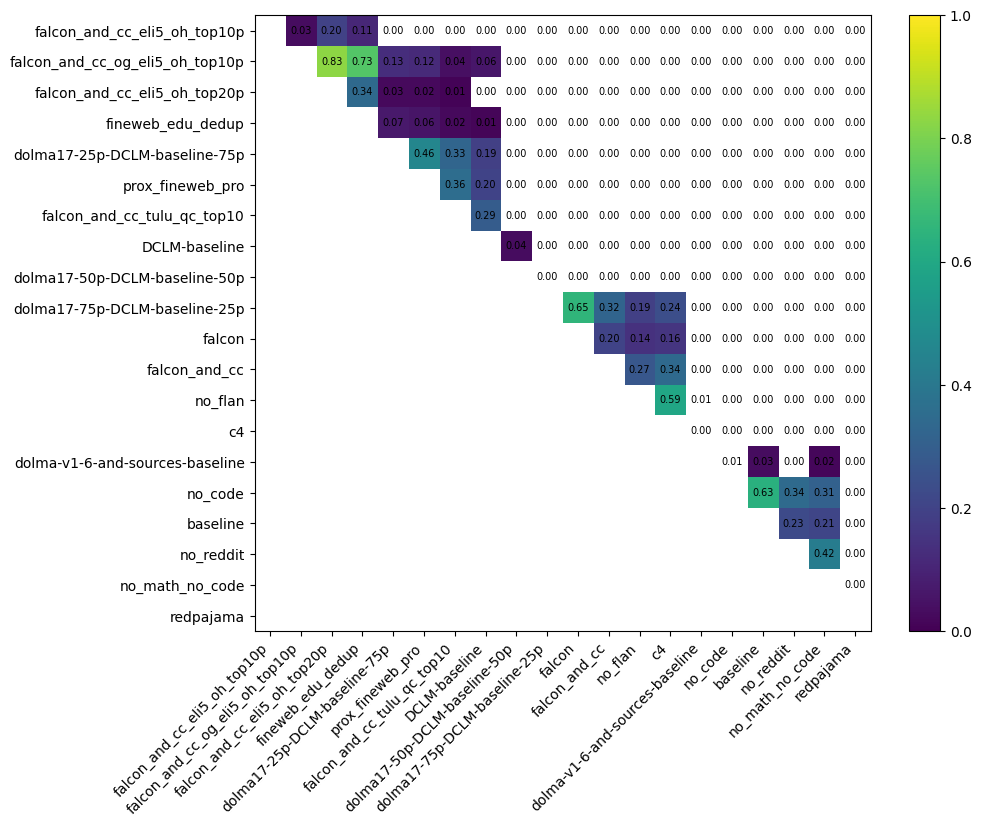

In [ ]:
import matplotlib.pyplot as plt
from plot import plot_heatmap

models = [model for model in MODELS if '1B' in model]
olmes = [task for task in TASKS if ':para' not in task and 'hellaswag' not in task]

mixes, scores = get_nd_array(df, 'mix', 'acc_per_char', model=models, task=olmes, step='max', sorted=True)
slices = get_slice(df, model=models, task=olmes)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax = plot_heatmap(ax, p_values, mixes, alpha=0.01)

### Fixing missing data @ 150M

In [ ]:
# Problem: Missing some evals for early checkpoints of 150M

curr_size = '150M'

curr_mixes = MIXES
curr_models = [model for model in MODELS if (curr_size in model) and any(mix in model for mix in curr_mixes)]

get_nd_array(df, ['mix', 'step'], 'acc_per_char', model=curr_models, task='arc_easy')

# pred_mixes, pred_compute = simulate_mix_selection('perc_sig', ['1B'], MIXES, 'arc_easy', top_n_clusters=top_n_clusters, alpha=alpha)

(2376, 179)


ValueError: cannot reshape array of size 425304 into shape (2376,20,9)